In [2]:
# baseline libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing libraries
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer

# model selection libraries
from sklearn.model_selection import train_test_split

# pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML models
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB

# hyperparameters tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.base import clone

#evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
#fix random_state for reproducibility
RANDOM_STATE = 42

# import development and evaluation set
development_set = pd.read_csv("development.csv")
evaluation_set = pd.read_csv("evaluation.csv")

# Data Collection & Exploration

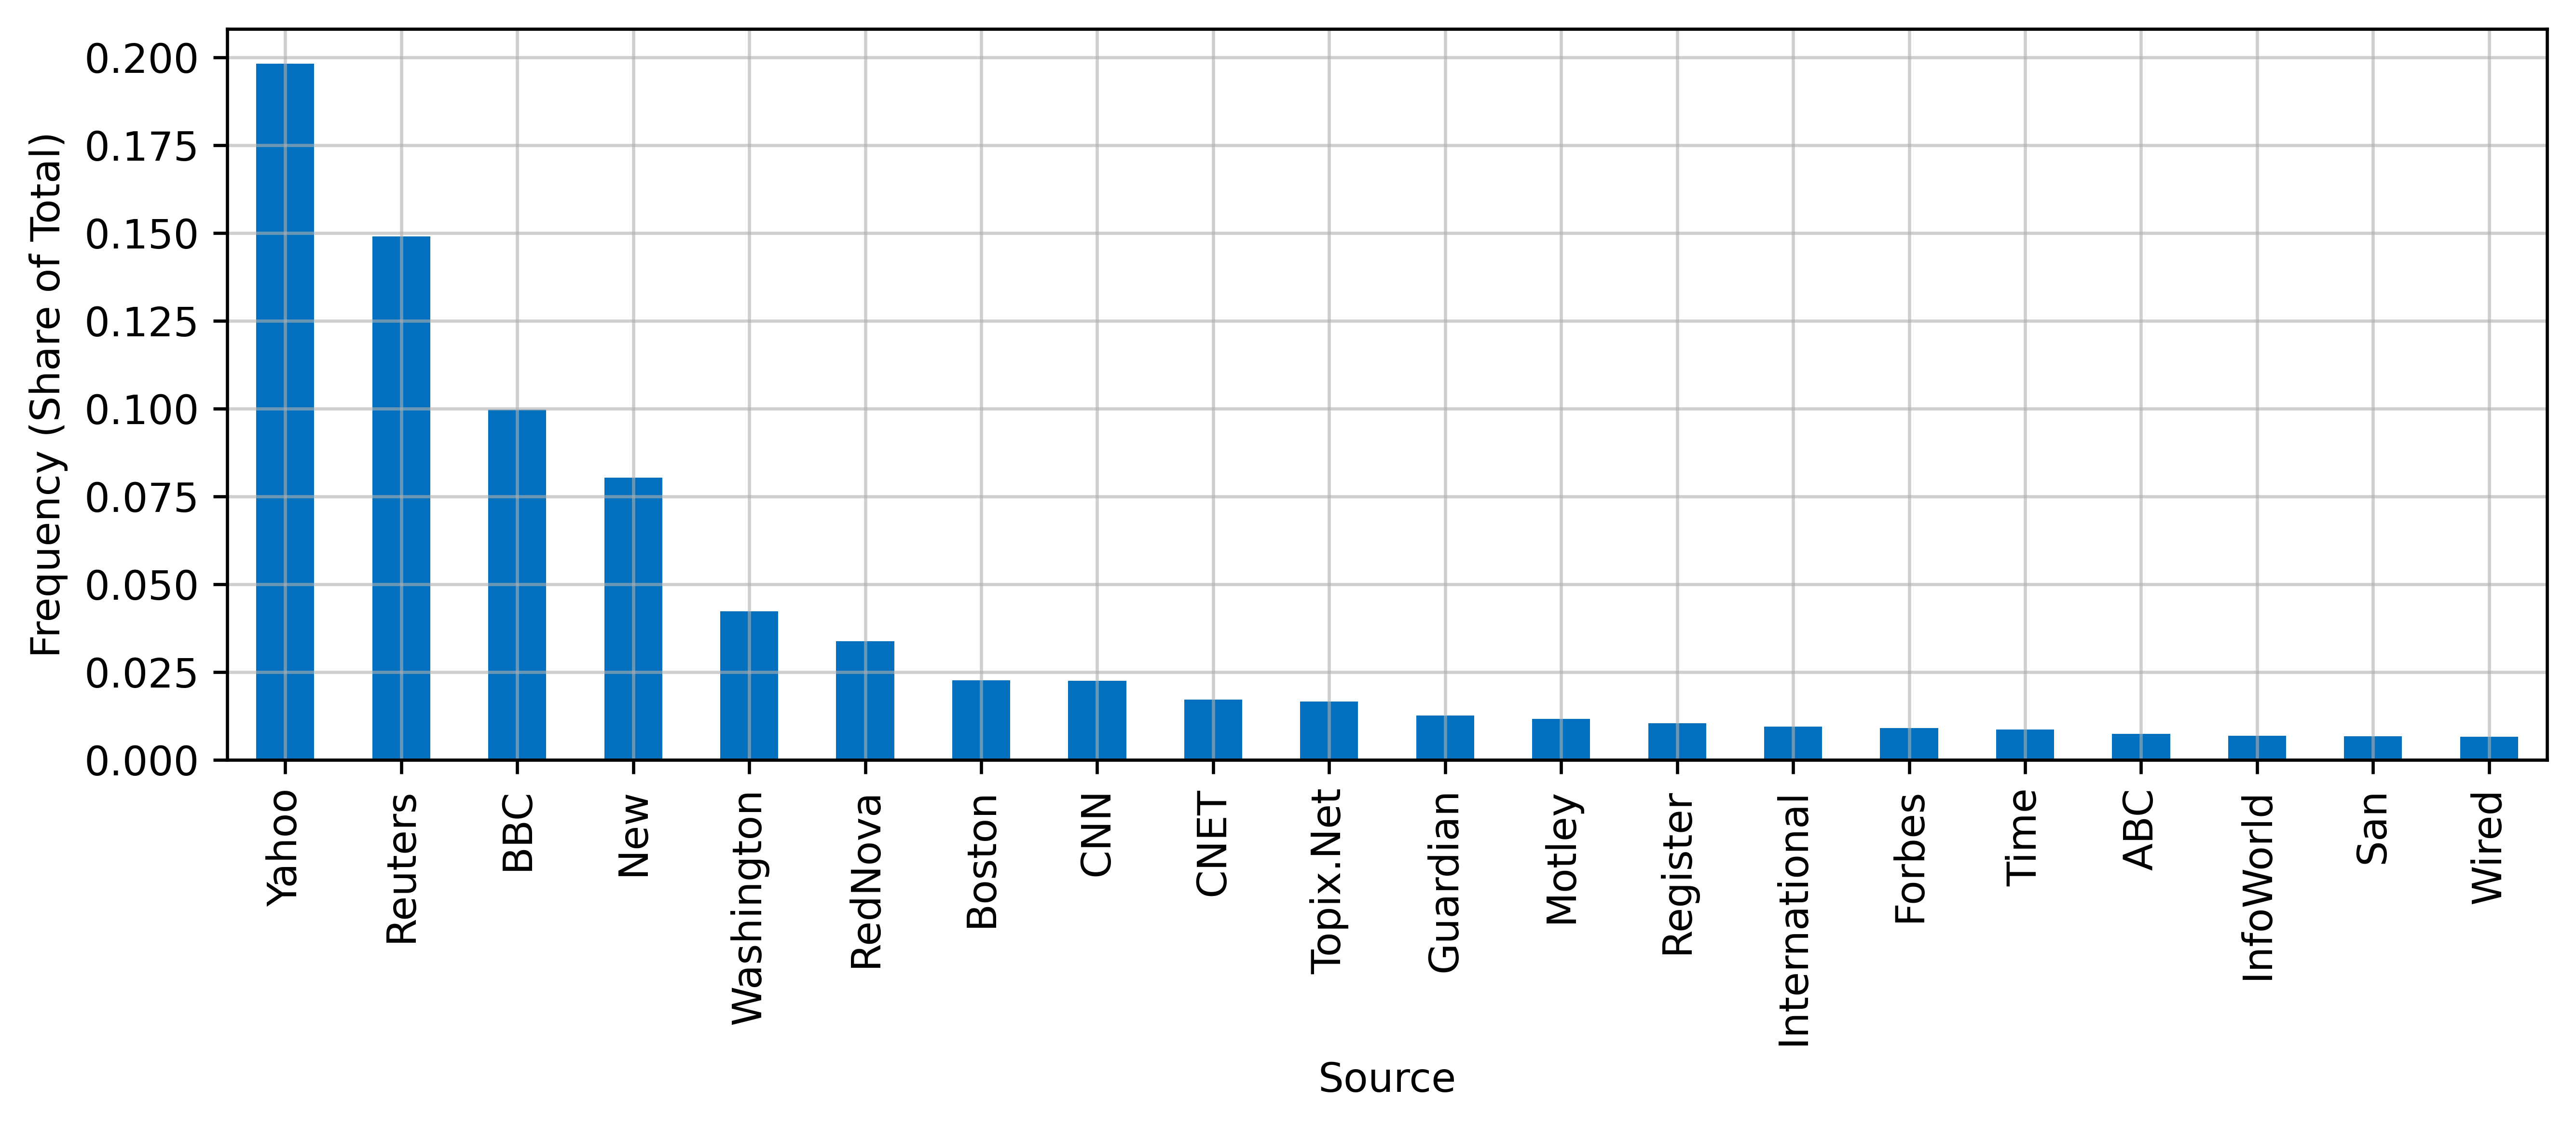

In [4]:
# 1. Analyze Top 20 Sources
# ------------------------------------------------------------
# Relative frequency
top_sources = development_set["source"].value_counts(normalize=True).head(20)

fig, ax = plt.subplots(figsize=(9, 4), dpi=600)
# Plot directly from the Series
top_sources.plot(kind='bar', color='#0270bf', ax=ax)

ax.set_xlabel("Source")
ax.set_ylabel("Frequency (Share of Total)")
ax.grid(True, alpha=0.6)

plt.tight_layout()
#fig.savefig("source_frequency.pdf", bbox_inches="tight") 
plt.show()

Length Statistics:
        title_words  article_words
count  79997.000000   79997.000000
mean       6.994175      35.769879
std        2.256556      39.438934
min        0.000000       0.000000
25%        5.000000      22.000000
50%        7.000000      30.000000
75%        8.000000      38.000000
max       45.000000    1888.000000


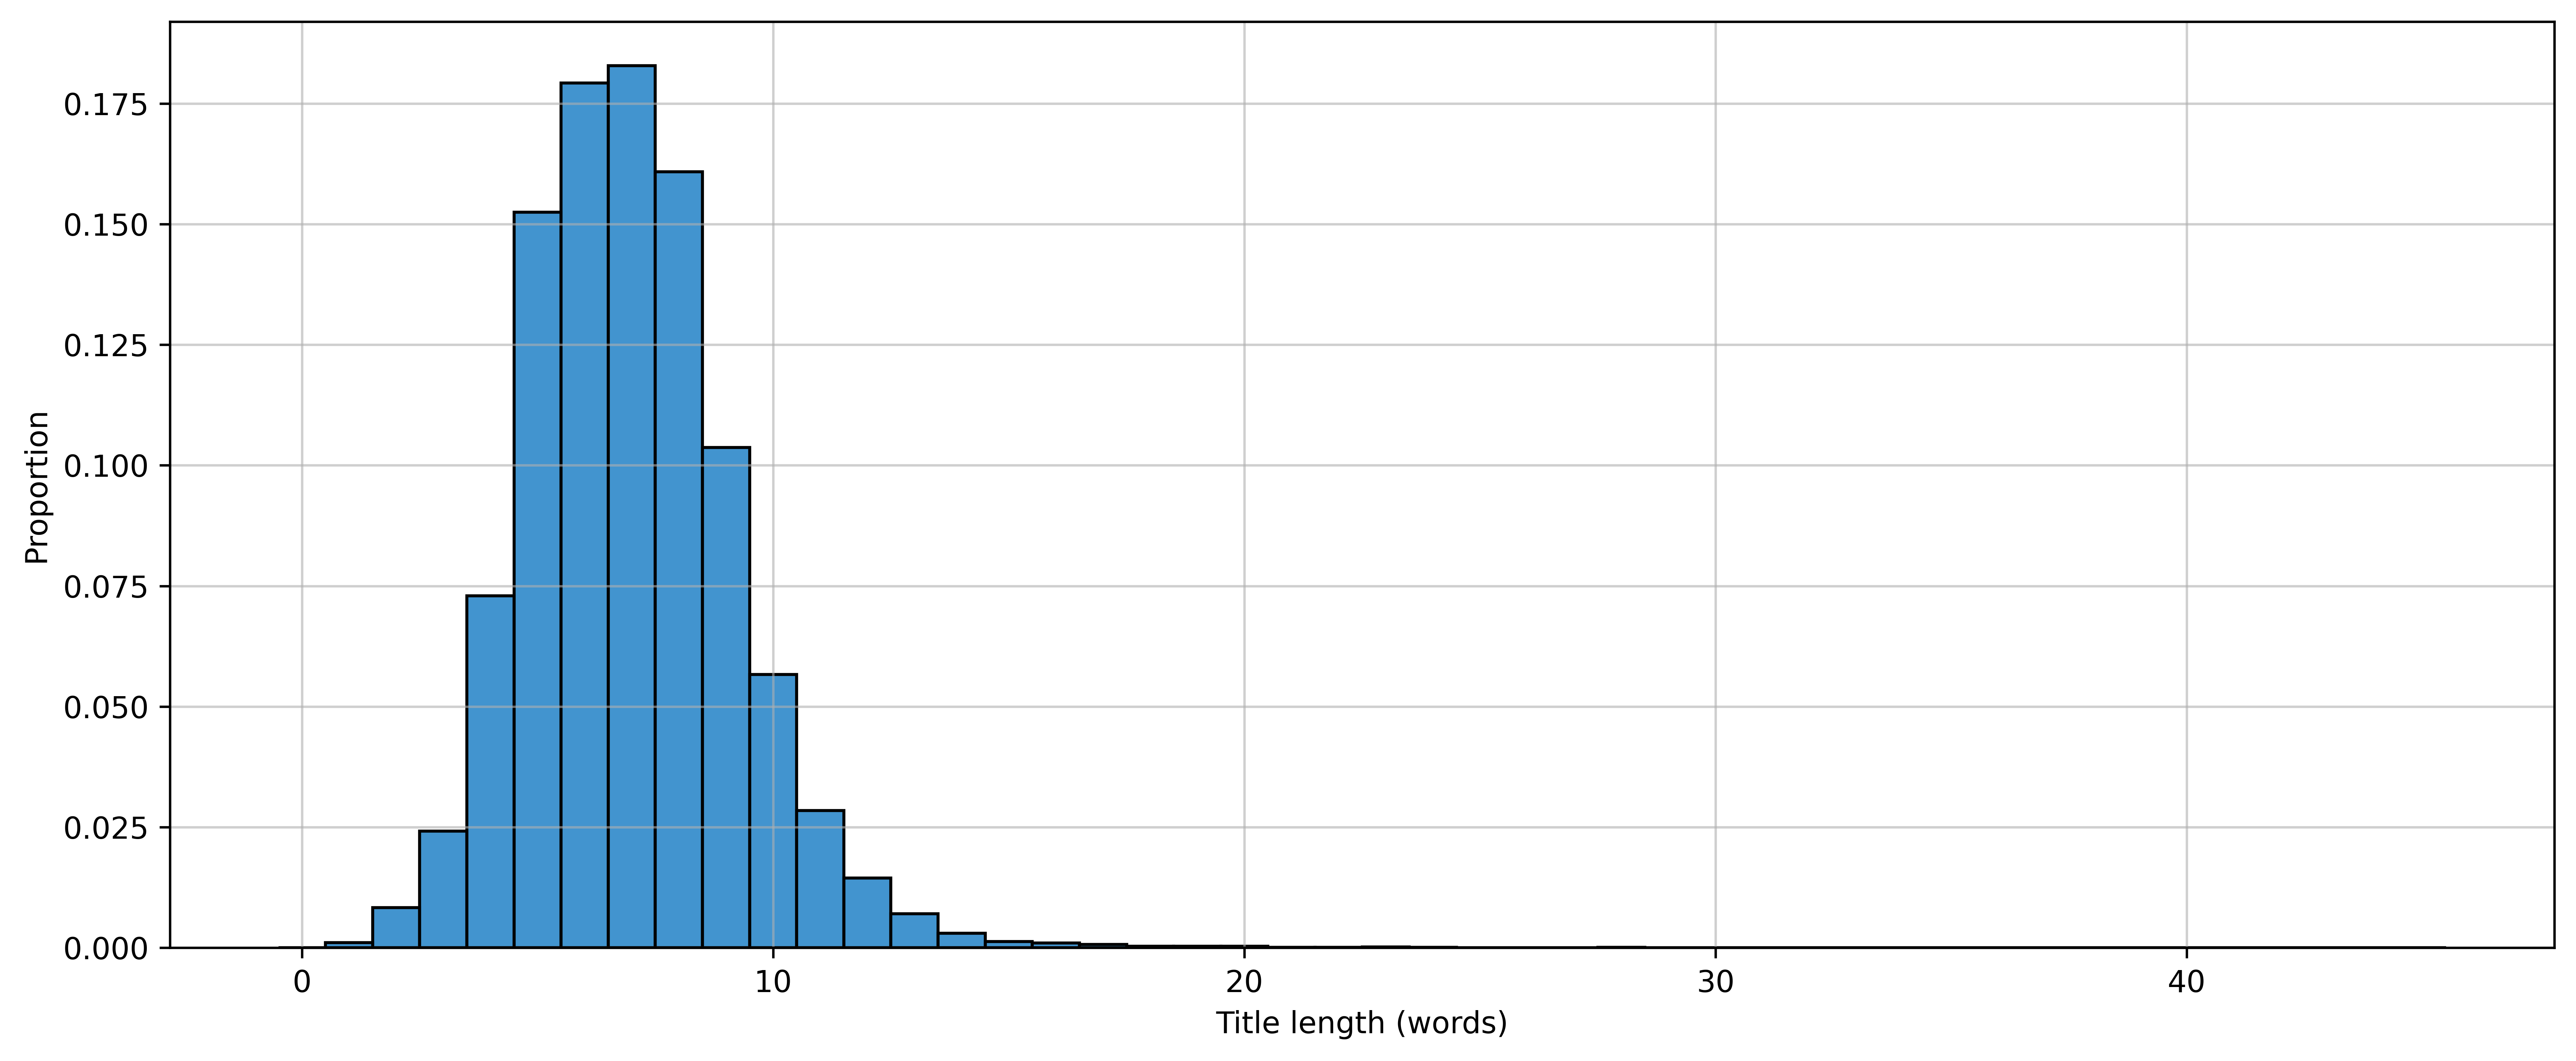

In [5]:
# 2. Article & Title Length Analysis
# ------------------------------------------------------------
df_length_ta = development_set.copy()

# Calculate Word Counts
df_length_ta["title_words"] = df_length_ta["title"].fillna("").apply(lambda x: len(str(x).split()))
df_length_ta["article_words"] = df_length_ta["article"].fillna("").apply(lambda x: len(str(x).split()))

# Descriptive Stats
print("Length Statistics:")
print(df_length_ta[["title_words", "article_words"]].describe())

# Plot Title Lengths
fig, ax = plt.subplots(figsize=(12, 5), dpi=600)
sns.histplot(
    data=df_length_ta,
    x="title_words",
    stat="proportion",
    discrete=True, # Better for small counts like titles
    color="#0270bf",
    ax=ax,
    rasterized=True
)
ax.set_xlabel("Title length (words)")
ax.grid(True, alpha=0.6)
plt.tight_layout()
#fig.savefig("title_lengths_frequency.pdf", bbox_inches="tight") 
plt.show()

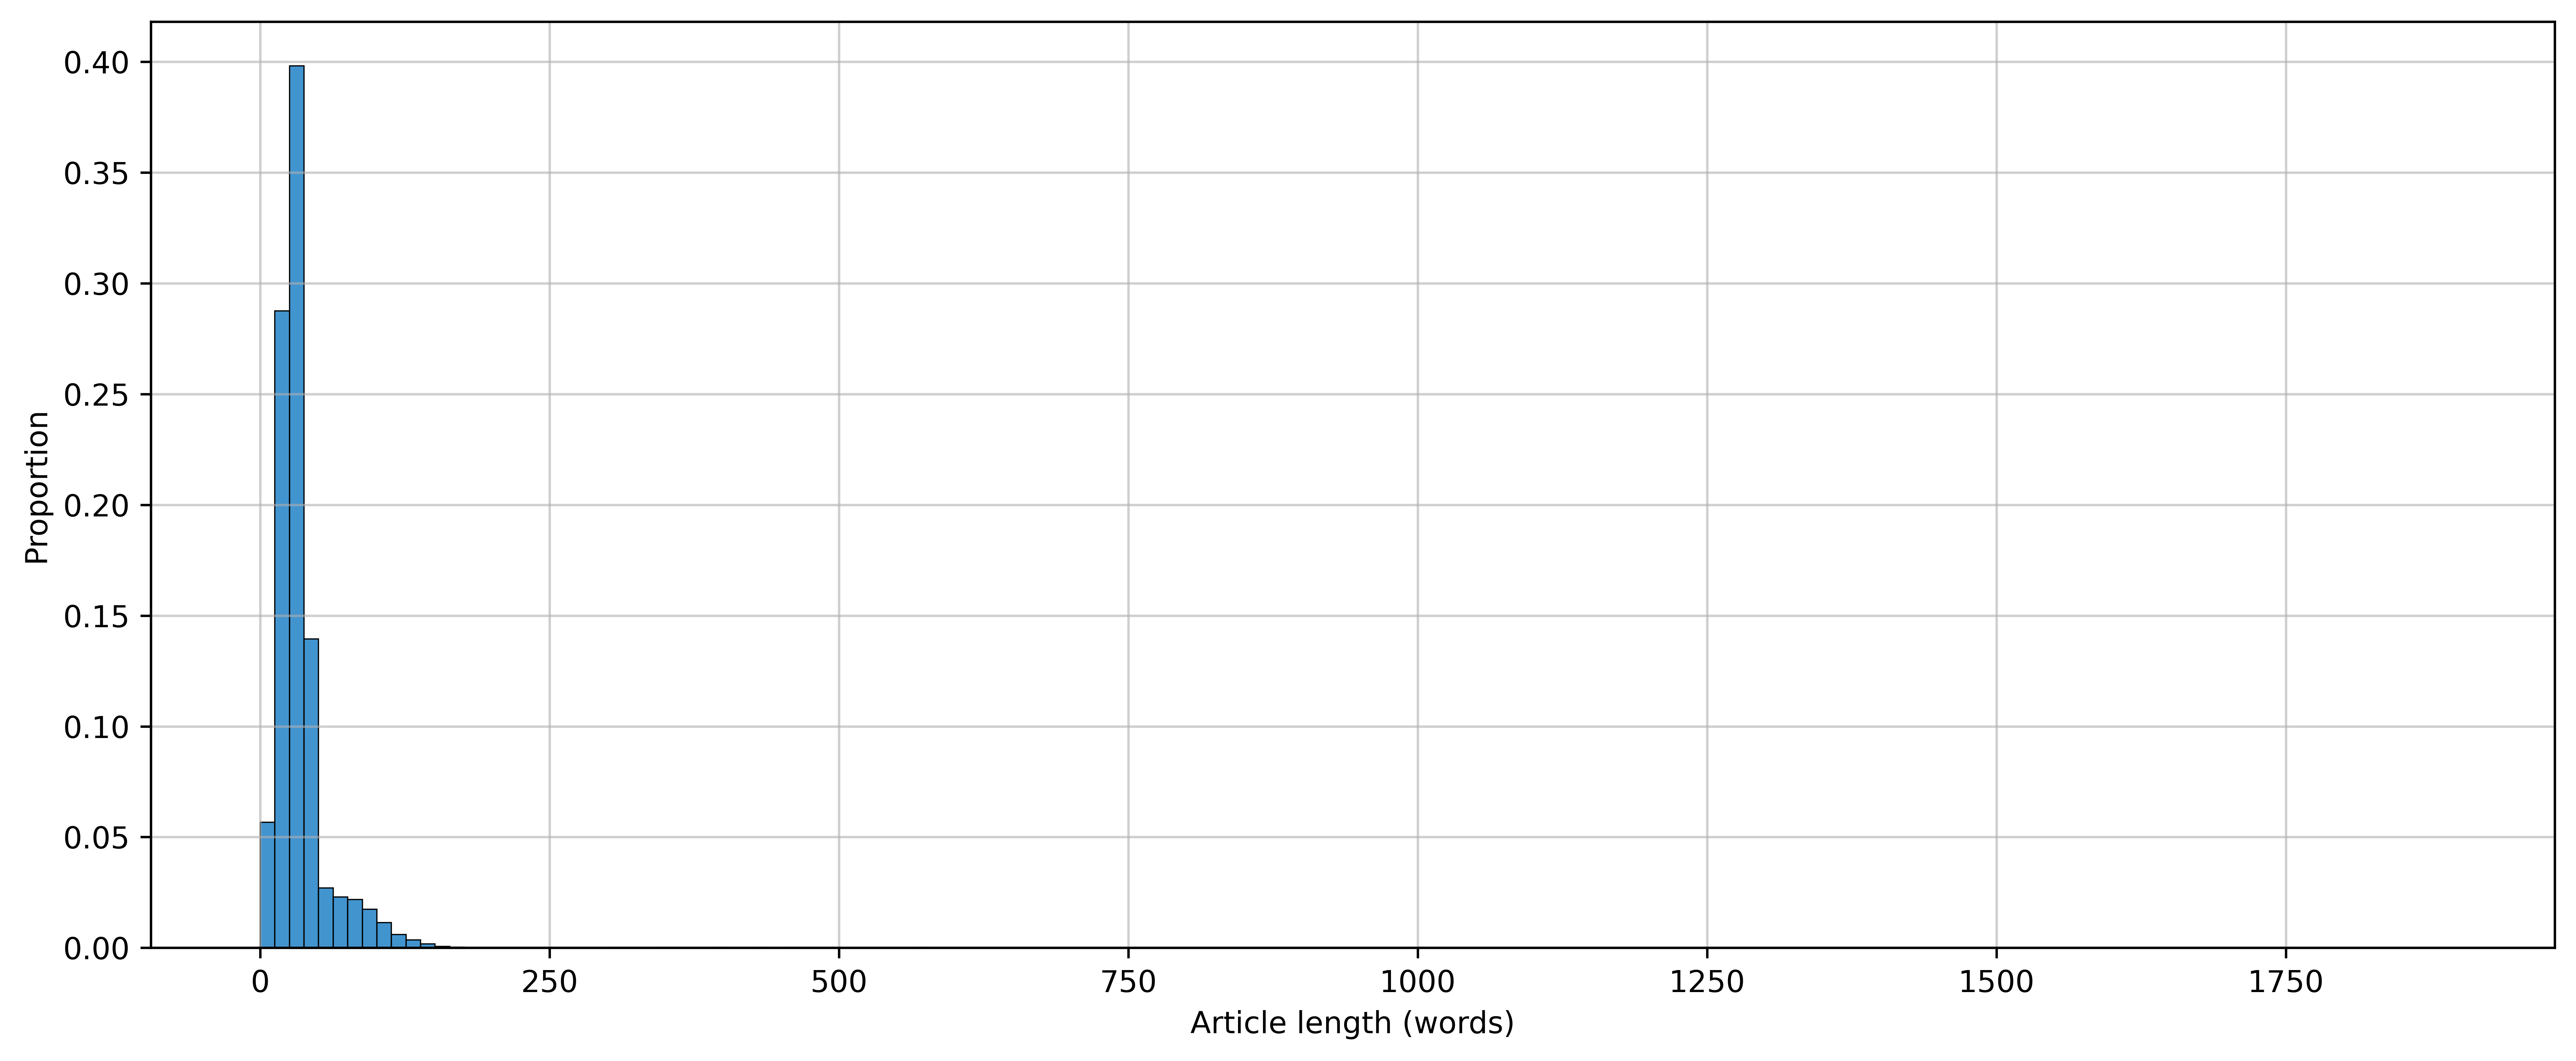

In [6]:
# Plot Article Lengths
fig, ax = plt.subplots(figsize=(12, 5), dpi=600)
sns.histplot(
    data=df_length_ta,
    x="article_words",
    stat="proportion",
    bins=150,
    color="#0270bf",
    ax=ax,
    rasterized=True
)
ax.set_xlabel("Article length (words)")
ax.grid(True, alpha=0.6)
plt.tight_layout()
#fig.savefig("article_lengthsfrequency.pdf", bbox_inches="tight") 
plt.show()

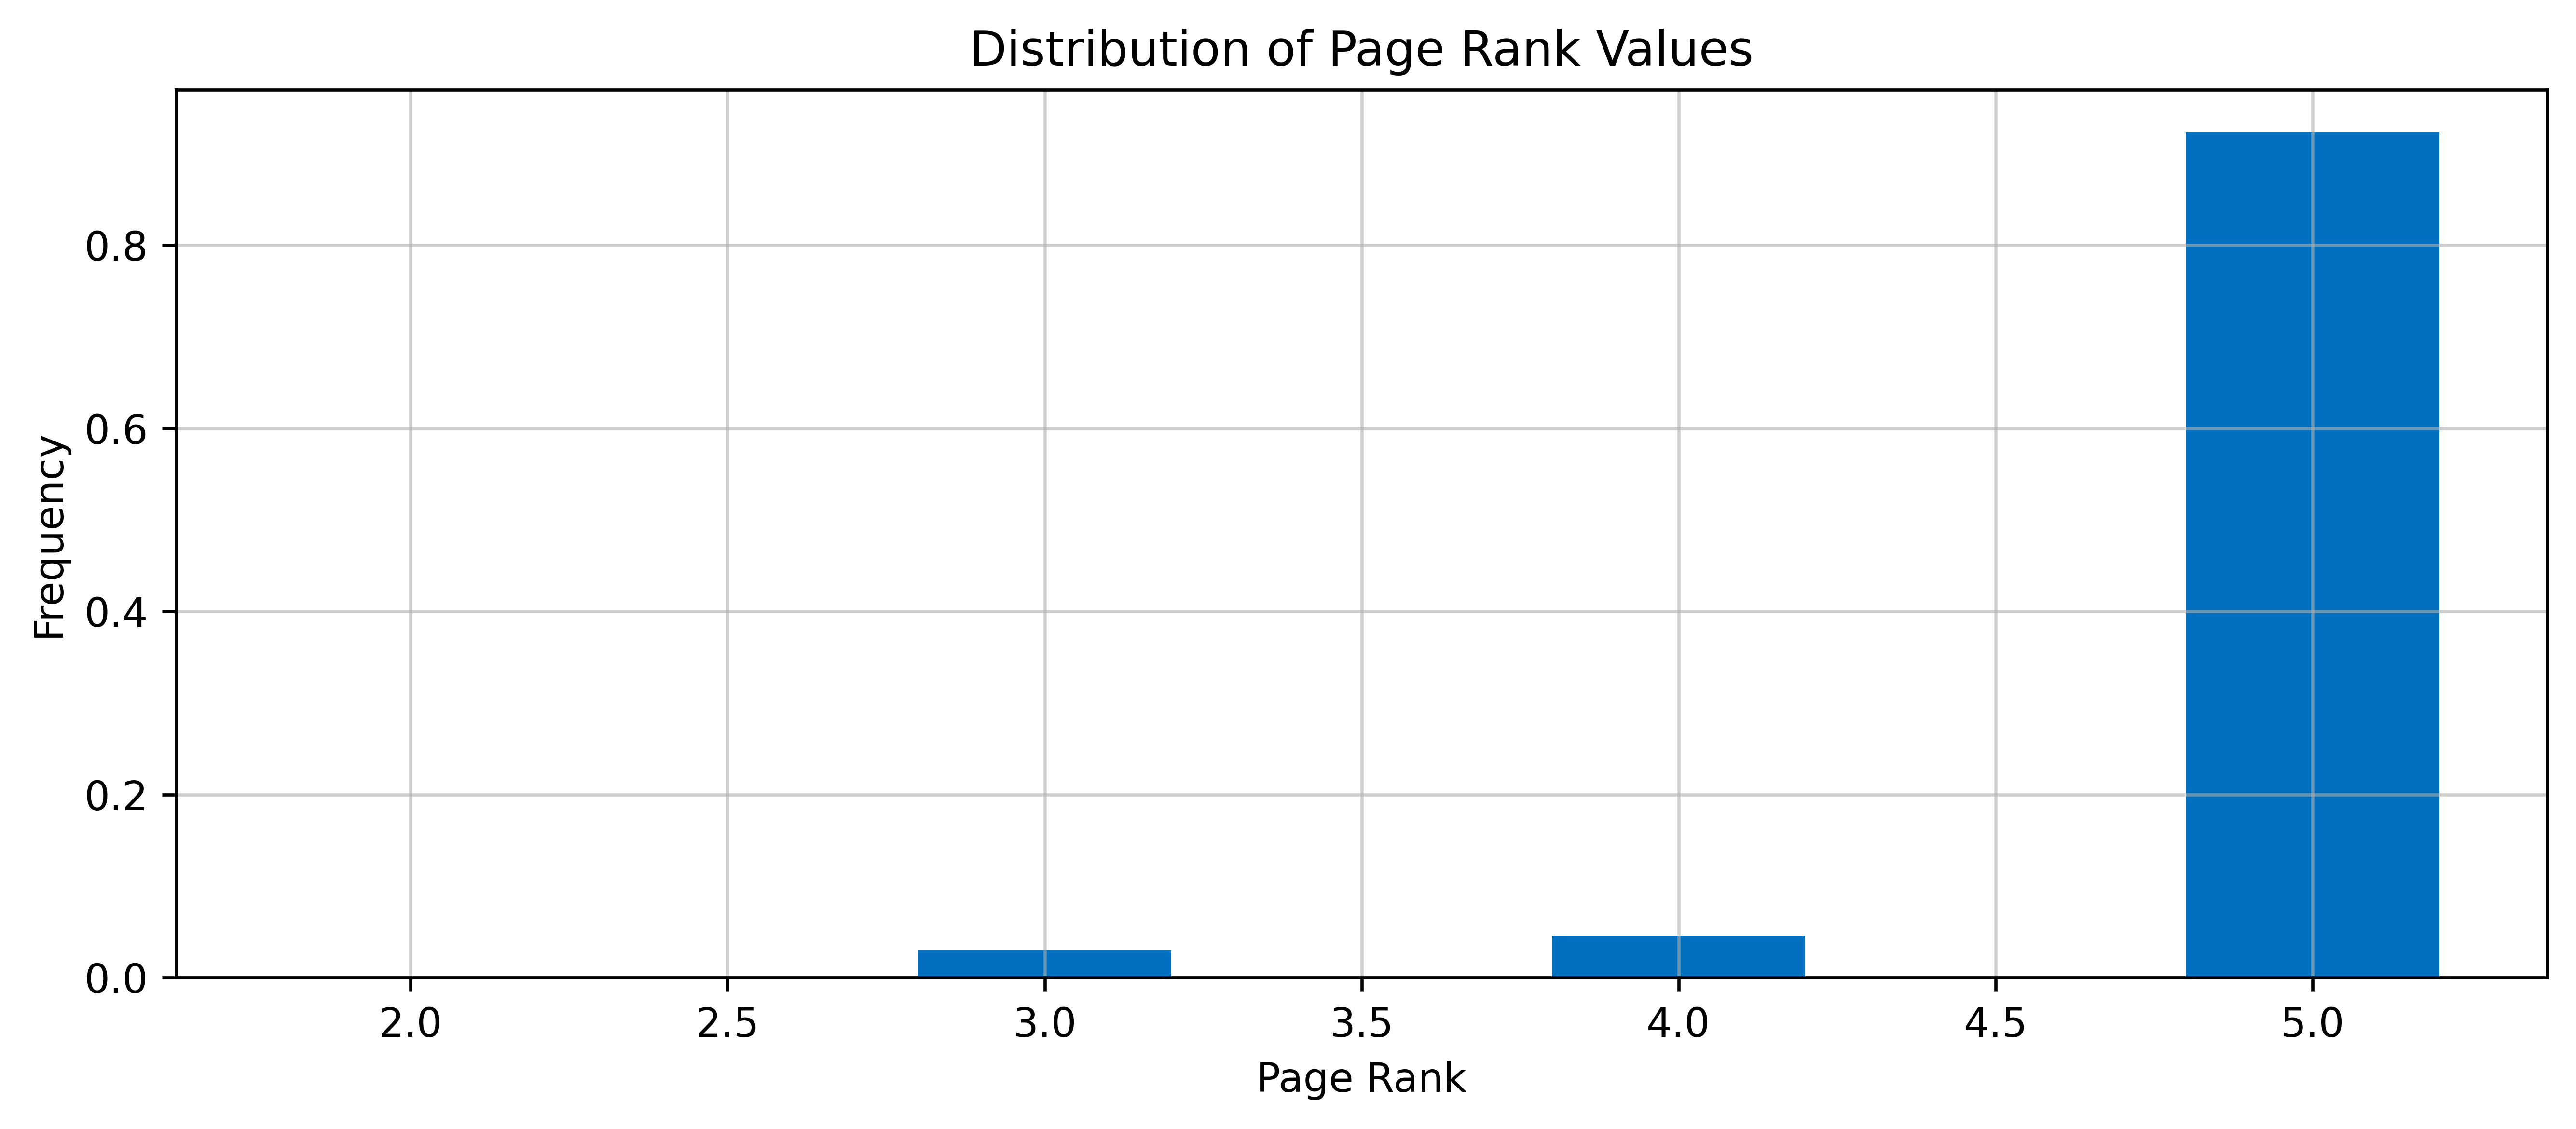

In [7]:
# 3. Page Rank Distribution
# ------------------------------------------------------------
pagerank_counts = development_set["page_rank"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(9, 4), dpi=600)
ax.bar(
    pagerank_counts.index,
    pagerank_counts.values,
    width=0.4,
    color='#0270bf'
)
ax.grid(True, alpha=0.6)
ax.set_xlabel("Page Rank")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Page Rank Values")
plt.tight_layout()
plt.show()

In [8]:
# 4. Missing Timestamps
# ------------------------------------------------------------
missing_mask = (development_set["timestamp"] == "0000-00-00 00:00:00") | (development_set["timestamp"].isna())
missing_pct = missing_mask.mean() * 100

print(f"Percentage of datetime missing/invalid: {round(missing_pct, 1)}%")

Percentage of datetime missing/invalid: 34.7%


/var/folders/48/rr_ylfv12t3fb01_brwwlvh00000gn/T/ipykernel_3497/3604252230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


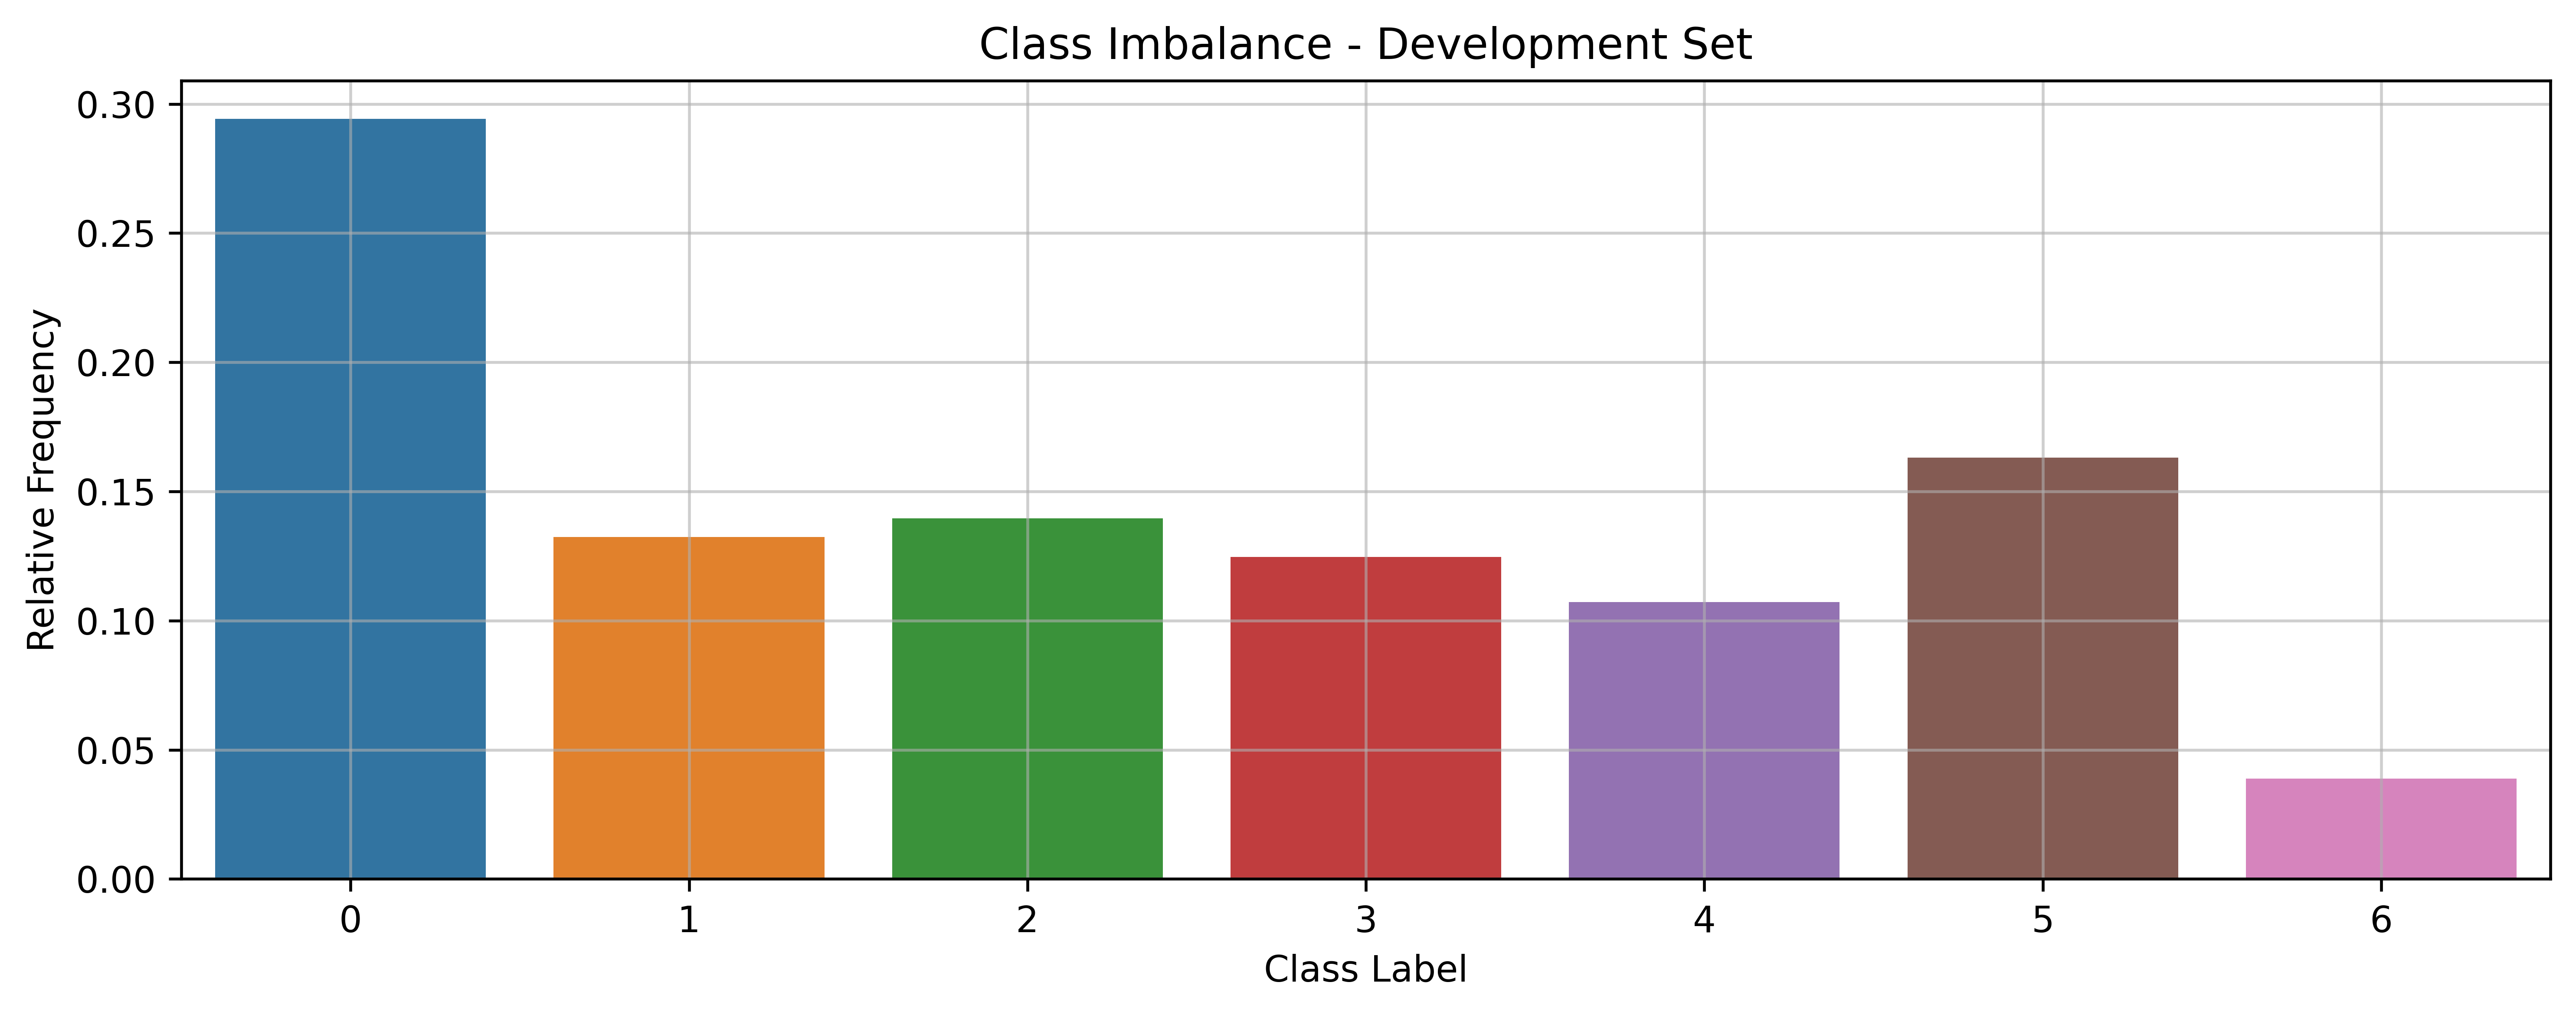

In [9]:
# 5. Label Distribution
# ------------------------------------------------------------
label_counts = development_set["label"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(10, 4), dpi=600)
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette="tab10", # seaborn handles n_colors automatically
    ax=ax 
)

ax.grid(True, alpha=0.6)
ax.set_xlabel("Class Label")
ax.set_ylabel("Relative Frequency")
ax.set_title("Class Imbalance - Development Set")
plt.tight_layout()
plt.show()

# Data Preparation/Preprocessing

In [10]:
def global_preprocessing(df):
    """
    Function that performs preprocessing for development set
    """ 
    df = df.copy()
    
    if "Id" in df.columns:
        df.set_index("Id", inplace=True)

    # Fill missing text
    df[["title", "article"]] = df[["title", "article"]].fillna("")
    # Feature engineering
    df["title_length"] = df["title"].apply(lambda x: len(str(x).split())) 
    df["article_length"] = df["article"].apply(lambda x: len(str(x).split())) 
    
    df.drop(columns=["timestamp"], inplace=True) 

    # Return X and y (if label exists)
    if "label" in df.columns:
        y = df["label"]
        X = df.drop(columns=["label"])
        return X, y
    else:
        # For evaluation set
        return df, None

In [11]:
# 1. Global Preprocessing 
# ------------------------------------------------------------
X, y = global_preprocessing(development_set)

In [12]:
# 2. Create Splits (80/20)
# ------------------------------------------------------------

# Train_val & Test
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    shuffle=True, 
    stratify=y # for unbalanced classes
)

print(f"Split Shapes: Train={X_train.shape}, Test={X_test.shape}")

Split Shapes: Train=(63997, 6), Test=(16000, 6)


# Hyperparameters Tuning

## - SVM

In [13]:
# ============================================================
# 1. SVM Pipeline
# ============================================================

# full default list of 150 words, i.e. the list called when we use stop_words=["english"] within TfidfVec
s_words = list(text.ENGLISH_STOP_WORDS)
#like s_words, but with Capital starting letter
s_words_firstcap = [w.capitalize() for w in s_words]
# complete list of words to delete
stop_words_full = s_words + s_words_firstcap


#Econders/Vectorizers
title_vectorizer = TfidfVectorizer( #fixed hyperparams
    lowercase=False,
    strip_accents="ascii",
    stop_words=stop_words_full,
    sublinear_tf=False #True for varying text lengths
) 

article_vectorizer = TfidfVectorizer( #fixed hyperparams
    lowercase=False,
    strip_accents="ascii",
    stop_words=stop_words_full,
    sublinear_tf=True #True for wide text lengths
) 

sources_encoder = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    sparse_output=True
)

#ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical_features", sources_encoder, ["source"]),
        ("title_feature", title_vectorizer, "title"),
        ("article_feature", article_vectorizer, "article"),
        ("ordinal_features", MinMaxScaler(), ["page_rank"]), #scaling required since SVM relies on distances
        ("continuous_features", MinMaxScaler(), ["article_length", "title_length"]) #scaling required since SVM relies on distances
    ],
    remainder="drop",
    sparse_threshold=1.0,
    n_jobs=-1
)

#Pipeline
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(
            dual="auto", 
            loss="squared_hinge",
            class_weight="balanced",
            random_state=RANDOM_STATE
            )
        )
    ]
)

### RandomizedSearchCV

In [14]:
# ============================================================
# 2. SVM - Random Search param distribution
# ============================================================

svm_param_distributions_rs = {
    # ---- TITLE ----
    "preprocessor__title_feature__ngram_range": [(1,2), (1,3)],
    "preprocessor__title_feature__min_df": [2, 5],
    "preprocessor__title_feature__max_df": [0.25, 0.5, 0.75],
    "preprocessor__title_feature__max_features": [None, 5000, 10000],

    # ---- ARTICLE ----
    "preprocessor__article_feature__ngram_range": [(1,2), (1,3)],
    "preprocessor__article_feature__min_df": [5, 10, 15],
    "preprocessor__article_feature__max_df": [0.4, 0.6, 0.8],

    # ---- SOURCE ----
    "preprocessor__categorical_features__min_frequency": [25, 50],

    # ---- SVM ----
    "classifier__C": [0.1, 0.3, 0.5, 0.7, 0.9],
    "classifier__max_iter": [5000, 10000]
}

In [15]:
# ============================================================
# 3. RandomizedSearch on Validation set - SVM
# ============================================================

random_search = RandomizedSearchCV(
    estimator=svm_pipeline, #Pipeline = preprocess Validation Set columns & text --> perform SVM
    param_distributions=svm_param_distributions_rs, #Dict of hyperparameters
    n_iter=50, #n of trials
    scoring="f1_macro", #combo that maximizes this score is the best between the n tried
    cv=5, # split according to custom one, previously defined
    n_jobs=-1, #full CPU power
    verbose=2, # how many info to display
    random_state=RANDOM_STATE,
    return_train_score=True # pay attention to overfitting
)

**PAY ATTENTION: the following cell requires several time, depending on the computational power of your machine**

In [16]:
# fit on training and score on validation: 
random_search.fit(X_train, y_train)

# print results
best_rs_score = random_search.best_score_ #contain the best score on validation set
best_rs_parameters = random_search.best_params_ #contain the corresponding hyperparameters to validation score
full_rs_results = random_search.cv_results_ #contain the full history "(hyperparams score)"

print(f"\n---------------\n\n---------------\n\n---------------\nBest F1-Macro achieved on Validation Set: {best_rs_score}\n---------------\nHyperparameters combo corresponding to best score: {best_rs_parameters}\n---------------\n")

# best pipeline, refitted on (train + validation) using the best validation hyperparameters
svm_best_model_rs = random_search.best_estimator_
print(f"\n---------------\n Best pipeline refitted on Train + Validation using optimal hyperparameters:\n {svm_best_model_rs}") 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END classifier__C=0.1, classifier__max_iter=5000, preprocessor__article_feature__max_df=0.6, preprocessor__article_feature__min_df=15, preprocessor__article_feature__ngram_range=(1, 3), preprocessor__categorical_features__min_frequency=50, preprocessor__title_feature__max_df=0.75, preprocessor__title_feature__max_features=10000, preprocessor__title_feature__min_df=2, preprocessor__title_feature__ngram_range=(1, 2); total time=  17.8s
[CV] END classifier__C=0.1, classifier__max_iter=5000, preprocessor__article_feature__max_df=0.6, preprocessor__article_feature__min_df=15, preprocessor__article_feature__ngram_range=(1, 3), preprocessor__categorical_features__min_frequency=50, preprocessor__title_feature__max_df=0.75, preprocessor__title_feature__max_features=10000, preprocessor__title_feature__min_df=2, preprocessor__title_feature__ngram_range=(1, 2); total time=  17.7s
[CV] END classifier__C=0.1, classifier__max_iter=500

/opt/homebrew/Caskroom/miniforge/base/envs/polito/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END classifier__C=0.9, classifier__max_iter=5000, preprocessor__article_feature__max_df=0.8, preprocessor__article_feature__min_df=5, preprocessor__article_feature__ngram_range=(1, 2), preprocessor__categorical_features__min_frequency=50, preprocessor__title_feature__max_df=0.5, preprocessor__title_feature__max_features=5000, preprocessor__title_feature__min_df=2, preprocessor__title_feature__ngram_range=(1, 2); total time=  20.0s
[CV] END classifier__C=0.9, classifier__max_iter=5000, preprocessor__article_feature__max_df=0.8, preprocessor__article_feature__min_df=5, preprocessor__article_feature__ngram_range=(1, 2), preprocessor__categorical_features__min_frequency=50, preprocessor__title_feature__max_df=0.5, preprocessor__title_feature__max_features=5000, preprocessor__title_feature__min_df=2, preprocessor__title_feature__ngram_range=(1, 2); total time=  20.4s
[CV] END classifier__C=0.9, classifier__max_iter=5000, preprocessor__article_feature__max_df=0.8, preprocessor__article_

In [17]:
#visualize the best model after RandomizedSearchCV
svm_best_model_rs

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('title_feature', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

### GridSearchCV - Tune C parameter

In [18]:
# ============================================================
# 4. SVM - Pipeline with new hyperparams from RS
# ============================================================

#recall the previous pipeline, and substitute the hyperparameters found with RS
svm_pipeline_gs_C = clone(svm_pipeline)
svm_pipeline_gs_C.set_params(**random_search.best_params_)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('title_feature', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [19]:
# ============================================================
# 5. SVM - GridSearch grid
# ============================================================

# C grid
param_grid_cv = {
    "classifier__C": [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
}

In [20]:
# ============================================================
# 6. GridSearchCV 
# ============================================================

grid_search = GridSearchCV(
    estimator=svm_pipeline_gs_C, #Pipeline = preprocess Validation Set columns & text --> perform SVM
    param_grid=param_grid_cv, #Dict of hyperparameters
    scoring="f1_macro", #combo that maximizes this score is the best between the n tried
    cv=5, # split according to custom one, previously defined
    n_jobs=-1, #full CPU power
    verbose=2, # score displayed
    return_train_score=True # pay attention to overfitting
)

**PAY ATTENTION: the following cell requires several time, depending on the computational power of your machine!**

In [21]:
# fit on training and score on validation: 
grid_search.fit(X_train, y_train)

# print results
best_gs_score = grid_search.best_score_ #contain the best score on validation set
best_gs_parameters = grid_search.best_params_ #contain the corresponding hyperparameters to validation score
full_gs_results = grid_search.cv_results_ #contain the full history "(hyperparams score)"

print(f"\n---------------\n\n---------------\n\n---------------\nBest F1-Macro achieved on Validation Set: {best_gs_score}\n---------------\nHyperparameters combo corresponding to best score: {best_gs_parameters}\n---------------\n")

# best pipeline, refitted on (train + validation) using the best validation hyperparameters
svm_best_model_gs = grid_search.best_estimator_
print(f"\n---------------\n Best pipeline refitted on Train + Validation using optimal hyperparameters:\n {svm_best_model_gs}") 

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END .................................classifier__C=0.01; total time=   5.4s
[CV] END .................................classifier__C=0.01; total time=   5.5s
[CV] END .................................classifier__C=0.01; total time=   5.5s
[CV] END .................................classifier__C=0.01; total time=   5.6s
[CV] END .................................classifier__C=0.01; total time=   5.6s
[CV] END .................................classifier__C=0.03; total time=   5.5s
[CV] END .................................classifier__C=0.03; total time=   5.5s
[CV] END .................................classifier__C=0.03; total time=   5.5s
[CV] END .................................classifier__C=0.03; total time=   5.6s
[CV] END .................................classifier__C=0.03; total time=   5.4s
[CV] END .................................classifier__C=0.05; total time=   5.5s
[CV] END .................................classif

In [22]:
svm_best_model_gs

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('title_feature', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

### Pt 3: BestHyperparams on test set

In [23]:
# Test the best model on test set
y_predtest = svm_best_model_gs.predict(X_test)
print(classification_report(y_test, y_predtest, digits=4))

              precision    recall  f1-score   support

           0     0.7676    0.7588    0.7631      4709
           1     0.7354    0.8201    0.7754      2118
           2     0.8358    0.8235    0.8296      2232
           3     0.6185    0.5258    0.5684      1995
           4     0.7832    0.9417    0.8552      1715
           5     0.5979    0.4914    0.5394      2611
           6     0.5830    0.8274    0.6840       620

    accuracy                         0.7255     16000
   macro avg     0.7030    0.7412    0.7165     16000
weighted avg     0.7211    0.7255    0.7200     16000



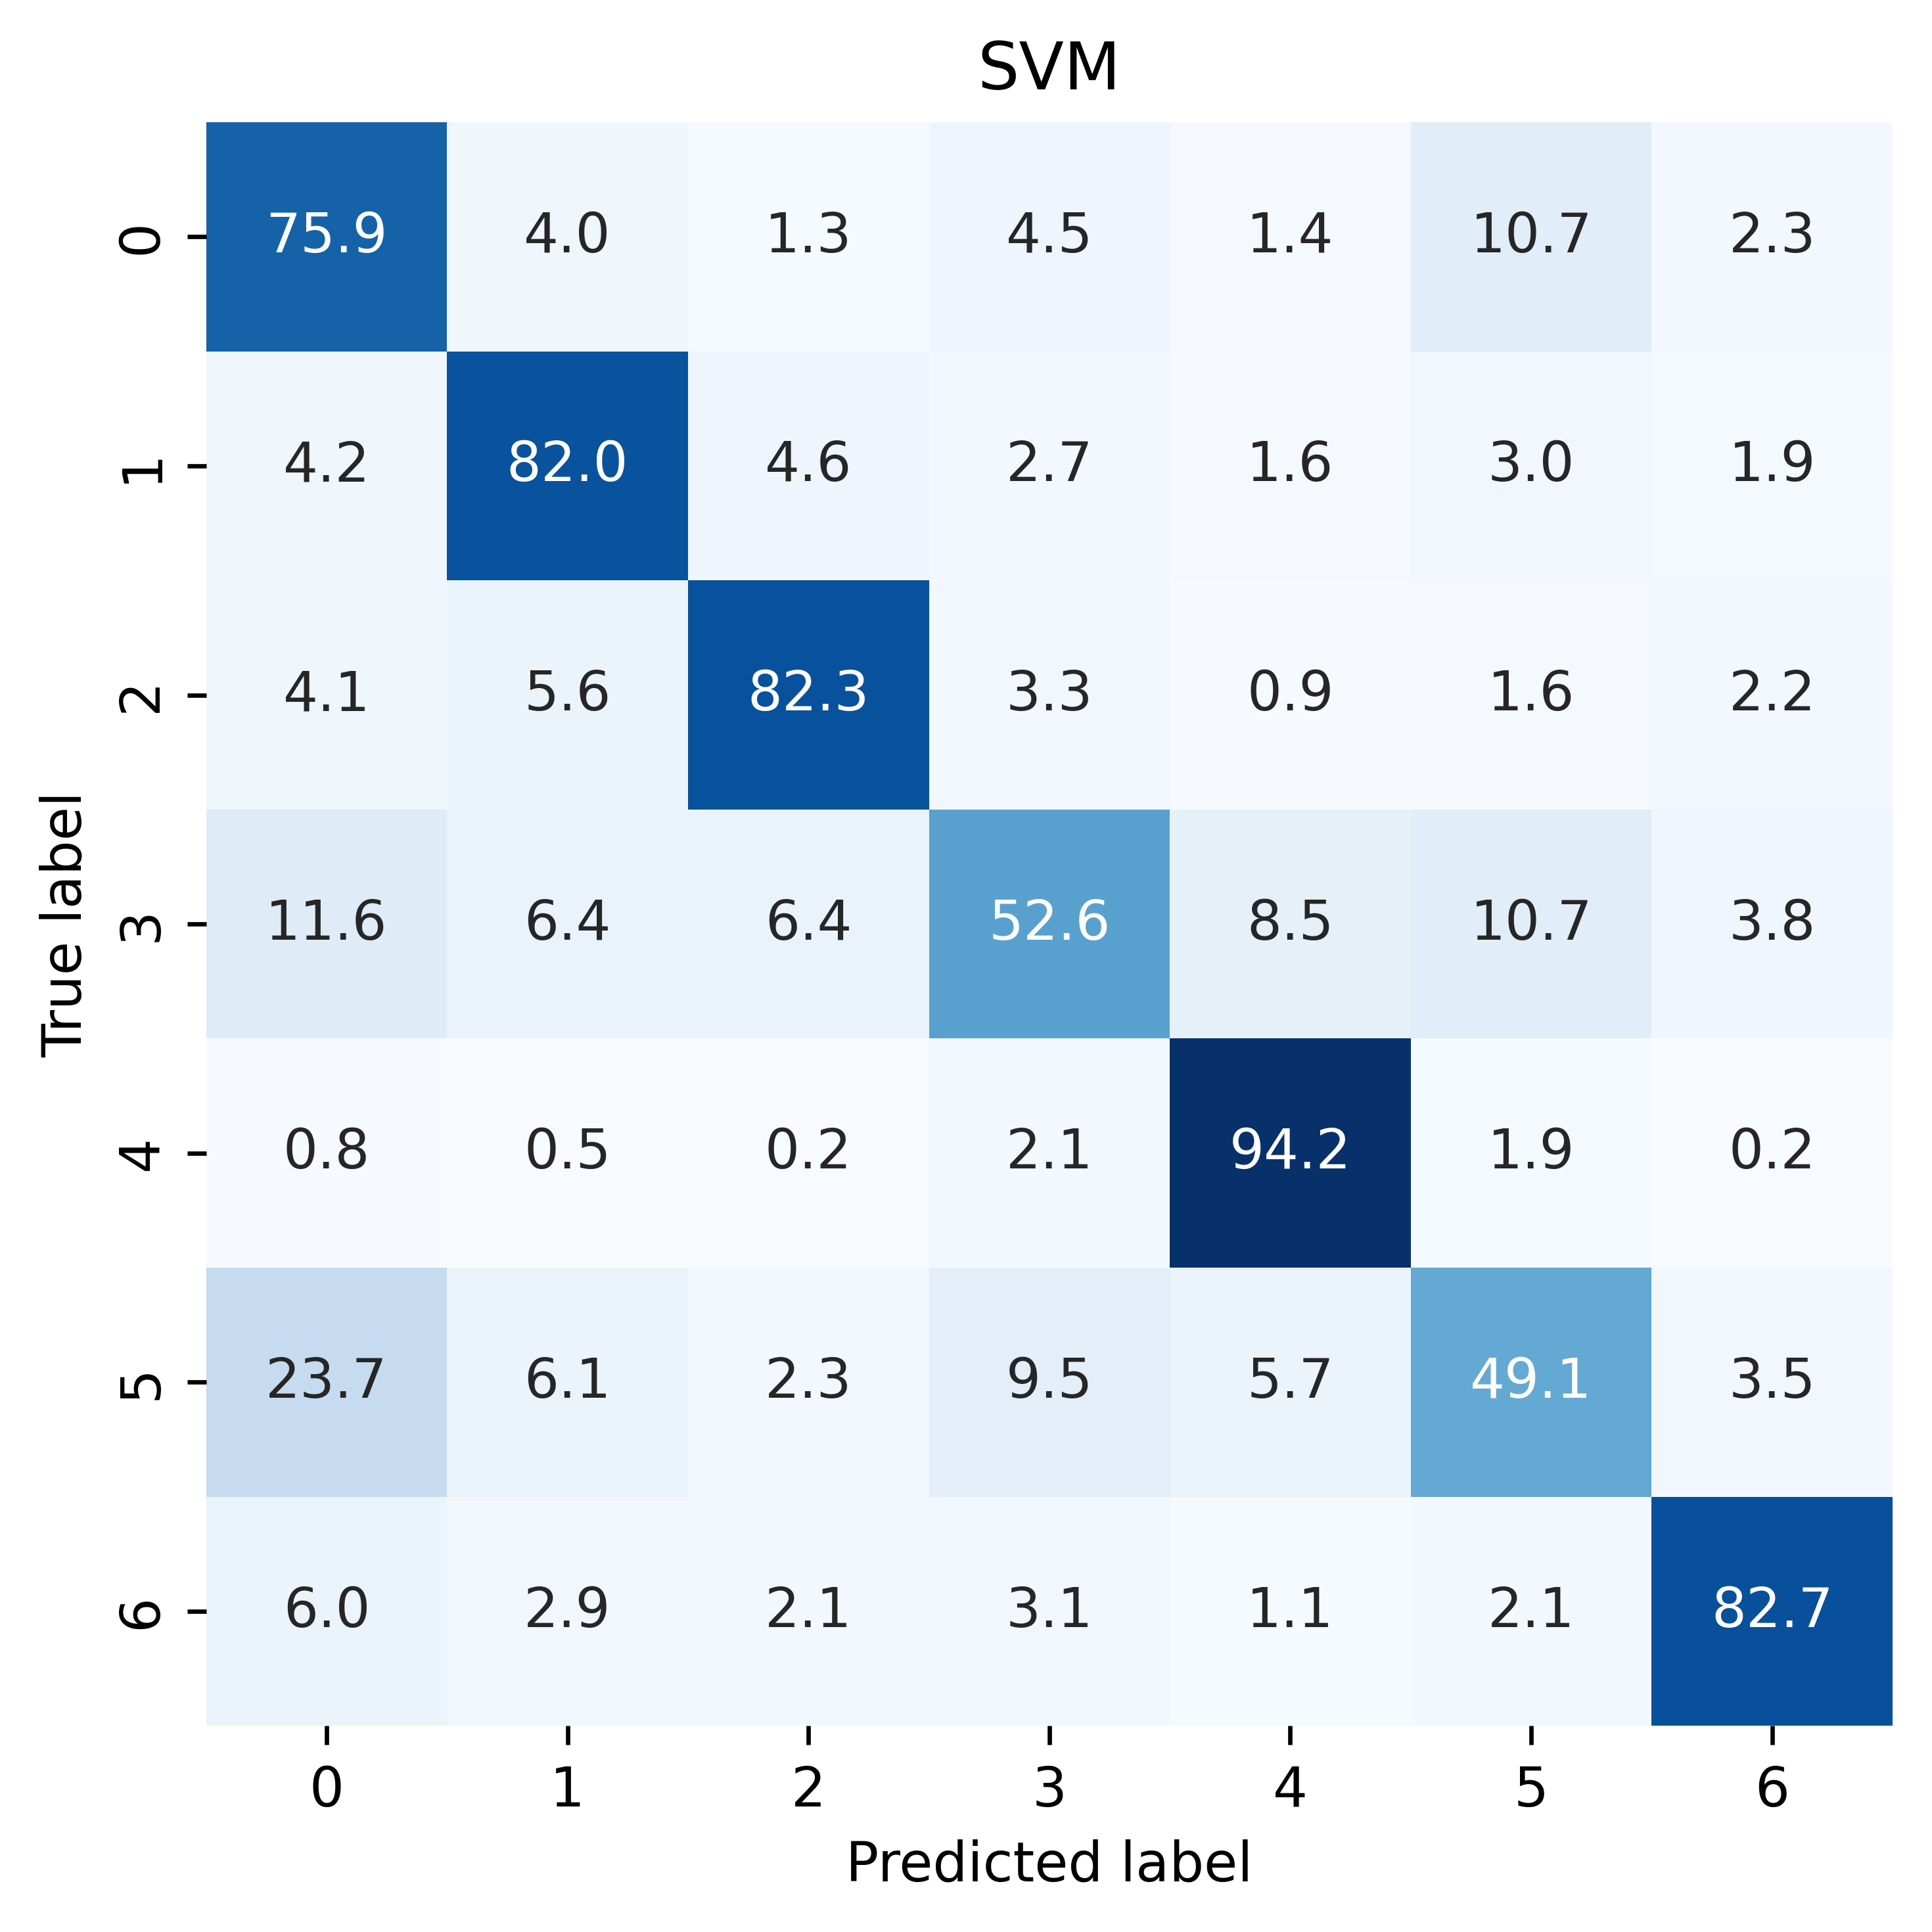

In [ ]:
cm = confusion_matrix(y_test, y_predtest) #confusion matrix (abs values)
cm_percenetages = cm/np.sum(cm, axis=1, keepdims=True) *100 #confusion matrix (showing %)

fig, ax = plt.subplots(figsize=(5, 5), dpi=600)

#plot confusion % 
sns.heatmap(
    cm_percenetages,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=False,
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("SVM")


plt.tight_layout()
plt.show()

#save it for the paper
#fig.savefig("SVM_confusion_matrix.pdf", bbox_inches="tight") 

## - Naive Bayes (ComplementNB)

In [25]:
# ============================================================
# 1. CNB Pipeline
# ============================================================

#Econders/Vectorizers
title_vectorizer = TfidfVectorizer( #fixed hyperparams
    lowercase=False,
    strip_accents="ascii",
    stop_words=stop_words_full,
    sublinear_tf=False #True for varying text lengths
) 

article_vectorizer = TfidfVectorizer( #fixed hyperparams
    lowercase=False,
    strip_accents="ascii",
    stop_words=stop_words_full,
    sublinear_tf=True #True for wide text lengths
) 

sources_encoder = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    sparse_output=True
)

#ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical_features", sources_encoder, ["source"]),
        ("title_feature", title_vectorizer, "title"),
        ("article_feature", article_vectorizer, "article")
    ],
    remainder="drop",
    sparse_threshold=1.0,
    n_jobs=-1
)


#Pipeline
nb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ComplementNB())
    ]
)

### Pt 1: RandomizedSearchCV

In [26]:
# ============================================================
# 2. CNB - RandomizedSearch param distribution 
# ============================================================

nb_param_distributions = {
    # ---- TITLE ----
    "preprocessor__title_feature__ngram_range": [(1,2), (1,3)],
    "preprocessor__title_feature__min_df": [1, 2, 5],
    "preprocessor__title_feature__use_idf": [True, False],
    "preprocessor__title_feature__norm" : ["l1", "l2", None],

    # ---- ARTICLE ----
    "preprocessor__article_feature__ngram_range": [(1,2), (1,3)],
    "preprocessor__article_feature__min_df": [2, 5, 10],
    "preprocessor__article_feature__use_idf": [True, False],
    "preprocessor__article_feature__norm" : ["l1", "l2", None],

    # ---- SOURCE ----
    "preprocessor__categorical_features__min_frequency": [30, 50, 75],

    # ---- ComplementNB ----
    "classifier__alpha": [0.01, 0.1, 0.5, 1, 1.5, 2],
    "classifier__norm" : [True, False]
}

In [27]:
# ============================================================
# 3. CNB - RandomizedSearch on Validation set
# ============================================================

random_search = RandomizedSearchCV(
    estimator=nb_pipeline, #Pipeline = preprocess Validation Set columns & text --> perform SVM
    param_distributions=nb_param_distributions, #Dict of hyperparameters
    n_iter=50, #n of trials
    scoring="f1_macro", #combo that maximizes this score is the best between the n tried
    cv=5, # split according to custom one, previously defined
    n_jobs=-1, #full CPU power
    verbose=2, # score displayed
    random_state=RANDOM_STATE,
    return_train_score=True # pay attention to overfitting
)

**PAY ATTENTION: the following cell requires several time, depending on the computational power of your machine**

In [28]:
# fit on training and score on validation: 
random_search.fit(X_train, y_train)

# print results
best_rs_score = random_search.best_score_ #contain the best score on validation set
best_rs_parameters = random_search.best_params_ #contain the corresponding hyperparameters to validation score
full_rs_results = random_search.cv_results_ #contain the full history "(hyperparams score)"

print(f"\n---------------\n\n---------------\n\n---------------\nBest F1-Macro achieved on Validation Set: {best_rs_score}\n---------------\nHyperparameters combo corresponding to best score: {best_rs_parameters}\n---------------\n")

# best pipeline, refitted on (train + validation) using the best validation hyperparameters
nb_best_model_rs = random_search.best_estimator_
print(f"\n---------------\n Best pipeline refitted on Train + Validation using optimal hyperparameters:\n {nb_best_model_rs}") 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END classifier__alpha=0.5, classifier__norm=True, preprocessor__article_feature__min_df=2, preprocessor__article_feature__ngram_range=(1, 2), preprocessor__article_feature__norm=l2, preprocessor__article_feature__use_idf=True, preprocessor__categorical_features__min_frequency=30, preprocessor__title_feature__min_df=5, preprocessor__title_feature__ngram_range=(1, 2), preprocessor__title_feature__norm=l2, preprocessor__title_feature__use_idf=False; total time=   4.6s
[CV] END classifier__alpha=0.5, classifier__norm=True, preprocessor__article_feature__min_df=2, preprocessor__article_feature__ngram_range=(1, 2), preprocessor__article_feature__norm=l2, preprocessor__article_feature__use_idf=True, preprocessor__categorical_features__min_frequency=30, preprocessor__title_feature__min_df=5, preprocessor__title_feature__ngram_range=(1, 2), preprocessor__title_feature__norm=l2, preprocessor__title_feature__use_idf=False; total t

### Pt 2: GridSearchCV

In [29]:
# ============================================================
# 4. CNB - Pipeline with new hyperparams from RS
# ============================================================

#recall the previous pipeline, and substitute the hyperparameters found with RS
nb_pipeline_gs_alpha = clone(nb_pipeline)
nb_pipeline_gs_alpha.set_params(**random_search.best_params_)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('title_feature', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [30]:
# ============================================================
# 5. CNB - GridSearch grid
# ============================================================

# alpha grid
param_grid_alpha = {
    "classifier__alpha": [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
}

In [31]:
nb_grid_search = GridSearchCV(
    estimator=nb_pipeline_gs_alpha, #Pipeline = preprocess Validation Set columns & text --> perform CNB
    param_grid=param_grid_alpha, #Dict of hyperparameters
    scoring="f1_macro", #combo that maximizes this score is the best between the n tried
    cv=5, # split according to custom one, previously defined
    n_jobs=-1, #full CPU power
    verbose=2, # score displayed
    return_train_score=True # pay attention to overfitting
)

**PAY ATTENTION: the following cell requires several time, depending on the computational power of your machine**

In [32]:
# fit on training and score on validation: 
nb_grid_search.fit(X_train, y_train)

# print results
nb_best_gs_score = nb_grid_search.best_score_ #contain the best score on validation set
nb_best_gs_parameters = nb_grid_search.best_params_ #contain the corresponding hyperparameters to validation score
nb_full_gs_results = nb_grid_search.cv_results_ #contain the full history "(hyperparams score)"

print(f"\n---------------\n\n---------------\n\n---------------\nBest F1-Macro achieved on Validation Set: {nb_best_gs_score}\n---------------\nHyperparameters combo corresponding to best score: {nb_best_gs_parameters}\n---------------\n")

# best pipeline, refitted on (train + validation) using the best validation hyperparameters
nb_best_model_gs = nb_grid_search.best_estimator_
print(f"\n---------------\n Best pipeline refitted on Train + Validation using optimal hyperparameters:\n {nb_best_model_gs}") 

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END .............................classifier__alpha=0.01; total time=   8.5s
[CV] END .............................classifier__alpha=0.01; total time=   8.7s
[CV] END .............................classifier__alpha=0.01; total time=   8.6s
[CV] END .............................classifier__alpha=0.03; total time=   8.2s
[CV] END .............................classifier__alpha=0.01; total time=   8.6s
[CV] END .............................classifier__alpha=0.03; total time=   8.5s
[CV] END .............................classifier__alpha=0.03; total time=   8.3s
[CV] END .............................classifier__alpha=0.03; total time=   8.4s
[CV] END .............................classifier__alpha=0.03; total time=   8.5s
[CV] END .............................classifier__alpha=0.01; total time=   8.8s
[CV] END .............................classifier__alpha=0.05; total time=   8.3s
[CV] END .............................classifier_

### Pt3: Best hyperparams on test set

In [33]:
nb_best_model_gs

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('title_feature', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [34]:
# TEST IT ON TEST SET
y_predtest_nb = nb_best_model_gs.predict(X_test)
print(classification_report(y_test, y_predtest_nb, digits=4))

              precision    recall  f1-score   support

           0     0.6874    0.7951    0.7373      4709
           1     0.7215    0.7866    0.7527      2118
           2     0.7727    0.8315    0.8010      2232
           3     0.6747    0.4657    0.5510      1995
           4     0.7513    0.9475    0.8381      1715
           5     0.6056    0.3658    0.4561      2611
           6     0.6166    0.7210    0.6647       620

    accuracy                         0.7014     16000
   macro avg     0.6899    0.7019    0.6858     16000
weighted avg     0.6930    0.7014    0.6871     16000



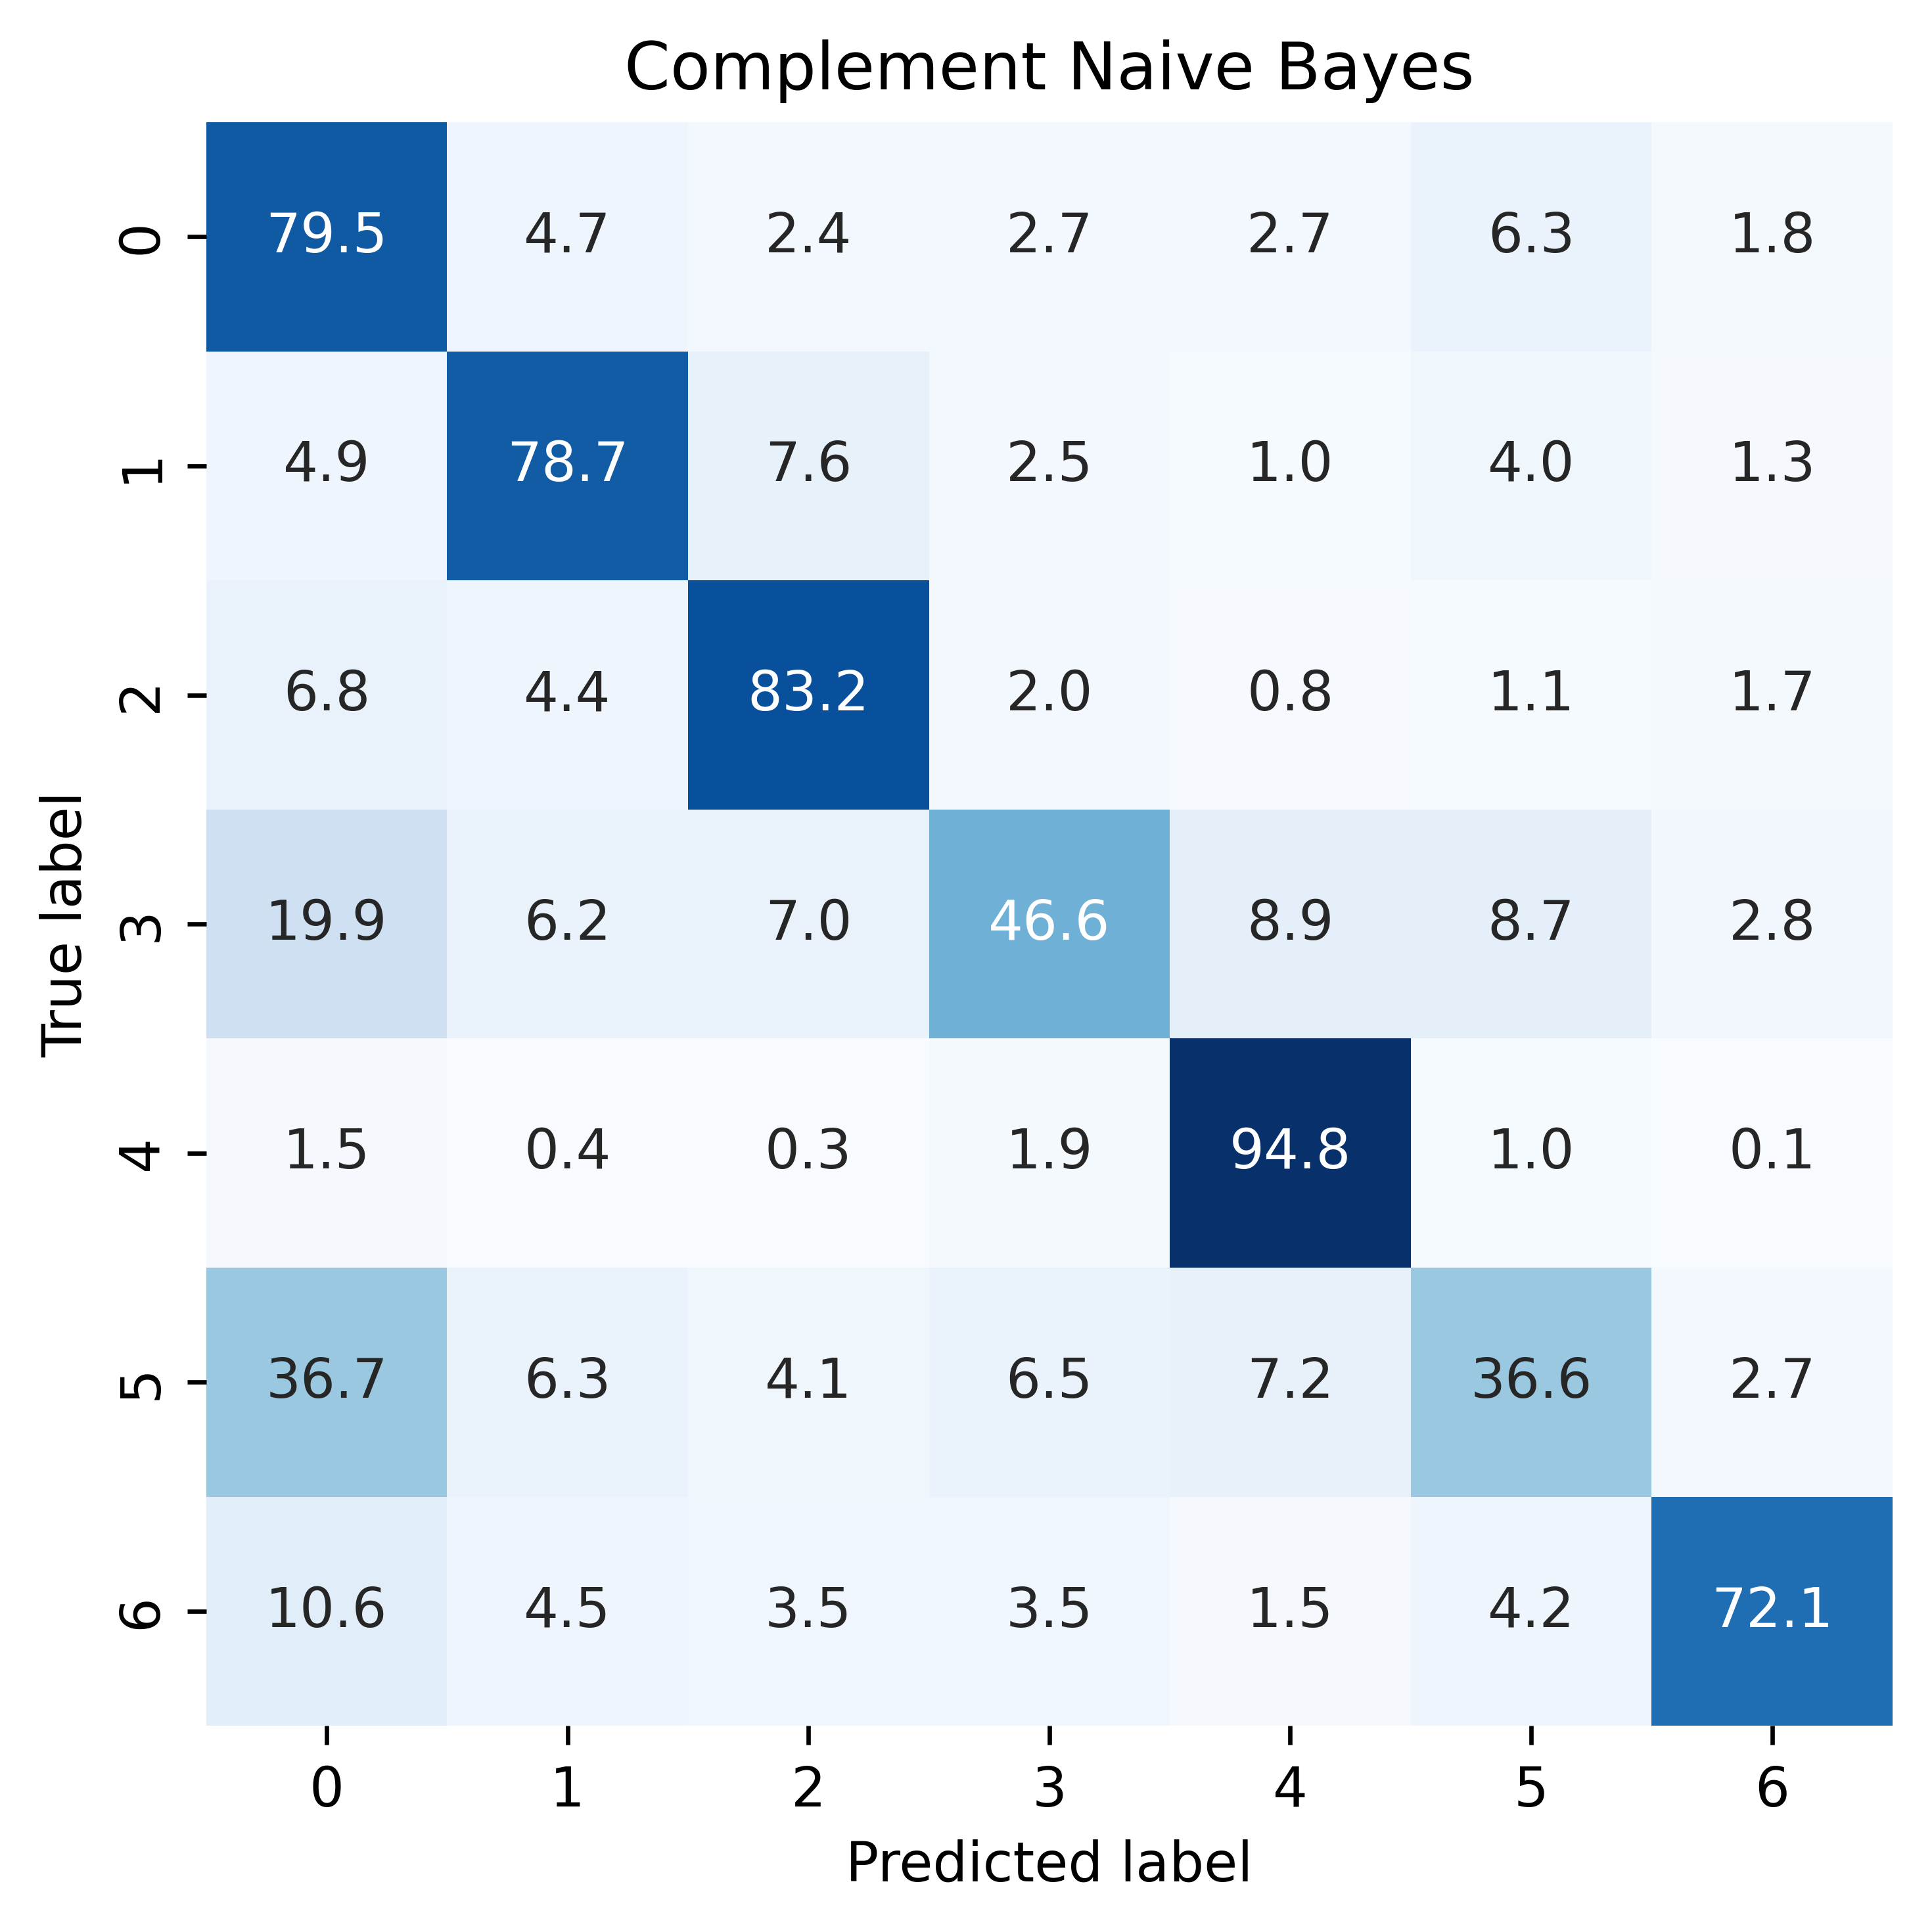

In [ ]:
cm = confusion_matrix(y_test, y_predtest_nb) #confusion matrix (abs values)
cm_percenetages = cm/np.sum(cm, axis=1, keepdims=True) *100 #confusion matrix (showing %)

fig, ax = plt.subplots(figsize=(5, 5), dpi=600)

#plot confusion % 
sns.heatmap(
    cm_percenetages,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=False,
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Complement Naive Bayes")


plt.tight_layout()
plt.show()

#save it for the paper
#fig.savefig("CNB_confusion_matrix.pdf", bbox_inches="tight") 